In [20]:
# Part - B 
# Project - 5

import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# Load Dataset

df = pd.read_csv("Smart_Outcome_Predictor_Dataset_5200.csv.csv")

print("Dataset Shape:")
print(df.shape)

print("\nFirst 5 Rows:")
print(df.head())

print("\nColumn Names:")
print(df.columns)

# Date Columan

df["course_start_date"] = pd.to_datetime(
    df["course_start_date"],
    errors="coerce"
)

df["start_year"] = df["course_start_date"].dt.year
df["start_month"] = df["course_start_date"].dt.month
df["start_day"] = df["course_start_date"].dt.day

df.drop("course_start_date", axis=1, inplace=True)

# 6 .Identify Features And Target

# ---------------- CLASSIFICATION ----------------

X_classification = df.drop(
    ["student_id", "completion_status", "final_score"],
    axis=1
)

y_classification = df["completion_status"]


# ---------------- REGRESSION ----------------

X_regression = df.drop(
    ["student_id", "completion_status", "final_score"],
    axis=1
)

y_regression = df["final_score"]

print("\nClassification Target:")
print("completion_status")

print("\nRegression Target:")
print("final_score")

print("\nFeatures:")
print(X_classification.columns.tolist())


# 7 .Train Test Split

# Classification split

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_classification,
    y_classification,
    test_size=0.20,
    random_state=42,
    stratify=y_classification
)


# Regression split

Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_regression,
    y_regression,
    test_size=0.20,
    random_state=42
)

print("Classification Training:", Xc_train.shape)
print("Classification Testing :", Xc_test.shape)

print("Regression Training:", Xr_train.shape)
print("Regression Testing :", Xr_test.shape)


#  8 .Basic Preprocessing

numeric_columns = X_classification.select_dtypes(
    include=["int64", "float64"]
).columns


# Find categorical columns

categorical_columns = X_classification.select_dtypes(
    include=["object"]
).columns


print("\nNumerical Columns:")
print(numeric_columns.tolist())

print("\nCategorical Columns:")
print(categorical_columns.tolist())


# ---------------- NUMERICAL PIPELINE ----------------

numeric_pipeline = Pipeline([
    
    # Missing numerical values
    ("imputer", SimpleImputer(strategy="median")),
    
    # Scaling
    ("scaler", StandardScaler())
])


# ---------------- CATEGORICAL PIPELINE ----------------

categorical_pipeline = Pipeline([
    
    # Missing categorical values
    ("imputer", SimpleImputer(strategy="most_frequent")),
    
    # Convert categorical values into numbers
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])


# ---------------- COLUMN TRANSFORMER ----------------

preprocessor = ColumnTransformer([
    
    ("numerical", numeric_pipeline, numeric_columns),
    
    ("categorical", categorical_pipeline, categorical_columns)
])


# Fit preprocessing

Xc_train_processed = preprocessor.fit_transform(Xc_train)

Xc_test_processed = preprocessor.transform(Xc_test)

Xr_train_processed = preprocessor.fit_transform(Xr_train)

Xr_test_processed = preprocessor.transform(Xr_test)


print("\nPreprocessing Completed Successfully!")

print("Classification Training Data:",
      Xc_train_processed.shape)

print("Regression Training Data:",
      Xr_train_processed.shape)

Dataset Shape:
(5200, 19)

First 5 Rows:
   student_id  age country_region device_type education_background  \
0      700001   32         Europe      Laptop            Undergrad   
1      700002   17         Europe      Laptop            Undergrad   
2      700003   25         Europe      Mobile             Graduate   
3      700004   26           Asia      Mobile            Undergrad   
4      700005   26           Asia      Tablet           WorkingPro   

   course_level course_category course_start_date  week_of_year  sessions  \
0  Intermediate        Business        2024-03-18            12         1   
1  Intermediate     Programming        2024-08-22            34        16   
2      Advanced     Programming        2024-09-28            39         6   
3      Beginner          Design        2024-03-09            10        34   
4      Advanced        Business        2024-03-21            12        22   

   time_spent_hours  videos_watched  quiz_attempts  assignments_submitted  

In [ ]:
# Part -C

from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import BaggingRegressor

from sklearn.metrics import accuracy_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

import numpy as np


#  9 .Bagging Classifer

print("\n Bagging Classifer")


base_classifier = DecisionTreeClassifier(
    max_depth=6,
    random_state=42
)


# Train base classifier

base_classifier.fit(
    Xc_train_processed,
    yc_train
)


# Prediction

base_prediction = base_classifier.predict(
    Xc_test_processed
)


# Accuracy

base_accuracy = accuracy_score(
    yc_test,
    base_prediction
)


print("\nSingle Decision Tree Accuracy:")
print(round(base_accuracy, 4))


#  Bagging Classifier

bagging_classifier = BaggingClassifier(
    estimator=DecisionTreeClassifier(
        max_depth=6,
        random_state=42
    ),
    n_estimators=50,
    random_state=42,
    n_jobs=-1
)


# Train Bagging

bagging_classifier.fit(
    Xc_train_processed,
    yc_train
)


# Prediction

bagging_prediction = bagging_classifier.predict(
    Xc_test_processed
)


# Accuracy

bagging_accuracy = accuracy_score(
    yc_test,
    bagging_prediction
)


print("\nBagging Classifier Accuracy:")
print(round(bagging_accuracy, 4))


# 10 Bagging Regressor

print("\n Bagging Regressor ")



base_regressor = DecisionTreeRegressor(
    max_depth=8,
    random_state=42
)


# Train

base_regressor.fit(
    Xr_train_processed,
    yr_train
)


# Prediction

base_regression_prediction = base_regressor.predict(
    Xr_test_processed
)


# Metrics

base_mae = mean_absolute_error(
    yr_test,
    base_regression_prediction
)

base_rmse = np.sqrt(
    mean_squared_error(
        yr_test,
        base_regression_prediction
    )
)

base_r2 = r2_score(
    yr_test,
    base_regression_prediction
)


print("\nSingle Decision Tree Regressor")

print("MAE :", round(base_mae, 4))
print("RMSE:", round(base_rmse, 4))
print("R2  :", round(base_r2, 4))

# Bagging Regressor

bagging_regressor = BaggingRegressor(
    estimator=DecisionTreeRegressor(
        max_depth=8,
        random_state=42
    ),
    n_estimators=50,
    random_state=42,
    n_jobs=-1
)


# Train

bagging_regressor.fit(
    Xr_train_processed,
    yr_train
)


# Prediction

bagging_regression_prediction = (
    bagging_regressor.predict(Xr_test_processed)
)


# Metrics

bag_mae = mean_absolute_error(
    yr_test,
    bagging_regression_prediction
)

bag_rmse = np.sqrt(
    mean_squared_error(
        yr_test,
        bagging_regression_prediction
    )
)

bag_r2 = r2_score(
    yr_test,
    bagging_regression_prediction
)


print("\nBagging Regressor")

print("MAE :", round(bag_mae, 4))
print("RMSE:", round(bag_rmse, 4))
print("R2  :", round(bag_r2, 4))


# 11 Comparison

print("\n Model Comparison ")


classification_result = pd.DataFrame({

    "Model": [
        "Decision Tree",
        "Bagging Classifier"
    ],

    "Accuracy": [
        base_accuracy,
        bagging_accuracy
    ]
})


print("\nCLASSIFICATION RESULT")
print(classification_result)



regression_result = pd.DataFrame({

    "Model": [
        "Decision Tree",
        "Bagging Regressor"
    ],

    "MAE": [
        base_mae,
        bag_mae
    ],

    "RMSE": [
        base_rmse,
        bag_rmse
    ],

    "R2 Score": [
        base_r2,
        bag_r2
    ]
})


print("\nREGRESSION RESULT")
print(regression_result)

# Final Result

print("\n Final Result ")



if bagging_accuracy > base_accuracy:

    print("Bagging Classifier performed BETTER.")

else:

    print("Single Decision Tree performed BETTER.")


if bag_r2 > base_r2:

    print("Bagging Regressor performed BETTER.")

else:

    print("Single Decision Tree performed BETTER.")



 Bagging Classifer

Single Decision Tree Accuracy:
0.7144

Bagging Classifier Accuracy:
0.7337

 Bagging Regressor 

Single Decision Tree Regressor
MAE : 8.9819
RMSE: 11.3081
R2  : 0.3156

Bagging Regressor
MAE : 7.9749
RMSE: 9.9474
R2  : 0.4704

 Model Comparison 

CLASSIFICATION RESULT
                Model  Accuracy
0       Decision Tree  0.714423
1  Bagging Classifier  0.733654

REGRESSION RESULT
               Model       MAE       RMSE  R2 Score
0      Decision Tree  8.981873  11.308054  0.315605
1  Bagging Regressor  7.974939   9.947429  0.470394

 Final Result 
Bagging Classifier performed BETTER.
Bagging Regressor performed BETTER.


(5200, 19)
   student_id  age country_region device_type education_background  \
0      700001   32         Europe      Laptop            Undergrad   
1      700002   17         Europe      Laptop            Undergrad   
2      700003   25         Europe      Mobile             Graduate   
3      700004   26           Asia      Mobile            Undergrad   
4      700005   26           Asia      Tablet           WorkingPro   

   course_level course_category course_start_date  week_of_year  sessions  \
0  Intermediate        Business        2024-03-18            12         1   
1  Intermediate     Programming        2024-08-22            34        16   
2      Advanced     Programming        2024-09-28            39         6   
3      Beginner          Design        2024-03-09            10        34   
4      Advanced        Business        2024-03-21            12        22   

   time_spent_hours  videos_watched  quiz_attempts  assignments_submitted  \
0               7.6         

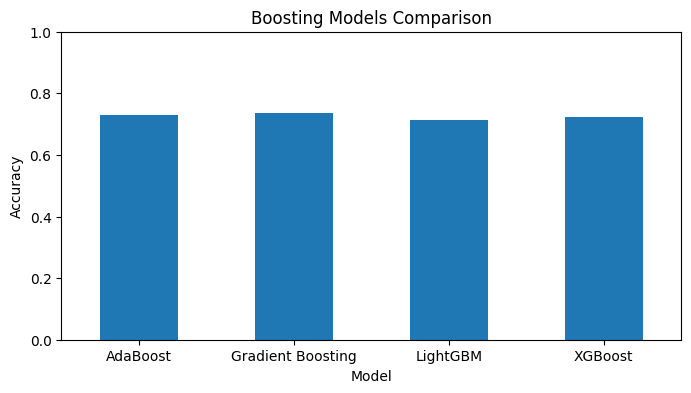

In [22]:
# Part - D 

import pandas as pd
import matplotlib.pyplot as plt
import time

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor

from sklearn.ensemble import (
    AdaBoostClassifier,
    AdaBoostRegressor,
    GradientBoostingClassifier,
    GradientBoostingRegressor
)

from sklearn.metrics import (
    accuracy_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# LightGBM
from lightgbm import LGBMClassifier, LGBMRegressor

# XGBoost
from xgboost import XGBClassifier, XGBRegressor


# Load dataset
df = pd.read_csv("Smart_Outcome_Predictor_Dataset_5200.csv.csv")

print(df.shape)
print(df.head())

# Remove ID and date
df = df.drop(columns=["student_id", "course_start_date"])

# Convert categorical columns into numbers
df = pd.get_dummies(df, drop_first=True)

print(df.shape)

# Check missing values
print(df.isnull().sum())

# Fill numerical missing values with median
df = df.fillna(df.median(numeric_only=True))

# Fill categorical missing values
df = df.fillna("Unknown")

# Check again
print(df.isnull().sum())

# 12 AdaBoost Classifier

X_c = df.drop(columns=["completion_status", "final_score"])
y_c = df["completion_status"]

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_c, y_c,
    test_size=0.20,
    random_state=42,
    stratify=y_c
)

model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=50,
    learning_rate=1.0,
    random_state=42
)

model.fit(X_train_c, y_train_c)

y_pred = model.predict(X_test_c)

print("\n AdaBoost Classifier")
print("Accuracy:", accuracy_score(y_test_c, y_pred))

# 13 AdaBoost Regressor

X_r = df.drop(columns=["final_score", "completion_status"])
y_r = df["final_score"]

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_r, y_r,
    test_size=0.20,
    random_state=42
)

model = AdaBoostRegressor(
    estimator=DecisionTreeRegressor(max_depth=2),
    n_estimators=50,
    learning_rate=0.5,
    random_state=42
)

model.fit(X_train_r, y_train_r)

y_pred = model.predict(X_test_r)

print("\n AdaBoost Regressor")
print("MAE:", mean_absolute_error(y_test_r, y_pred))
print("MSE:", mean_squared_error(y_test_r, y_pred))
print("R2 Score:", r2_score(y_test_r, y_pred))

# 14 Weak Learners Improve Sequentially

scores = []

for pred in model.staged_predict(X_test_r):
    scores.append(mean_absolute_error(y_test_r, pred))

print("\n Sequential Learning")
print(scores[:10])

# 15 Gradient Boosting Classifier

model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

model.fit(X_train_c, y_train_c)

y_pred = model.predict(X_test_c)

print("\n Gradient Boosting Classifier")
print("Accuracy:", accuracy_score(y_test_c, y_pred))

# 16 Gradient Boosting Regressor

model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

model.fit(X_train_r, y_train_r)

y_pred = model.predict(X_test_r)

print("\n Gradient Boosting Regressor")
print("MAE:", mean_absolute_error(y_test_r, y_pred))
print("MSE:", mean_squared_error(y_test_r, y_pred))
print("R2 Score:", r2_score(y_test_r, y_pred))

# 17 Learning Rate and Number of Estimators

for lr in [0.01, 0.05, 0.1, 0.2]:

    model = GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=lr,
        random_state=42
    )

    model.fit(X_train_c, y_train_c)

    pred = model.predict(X_test_c)

    print(
        "Learning Rate:", lr,
        "Accuracy:", accuracy_score(y_test_c, pred)
    )

for n in [25, 50, 100, 200]:

    model = GradientBoostingClassifier(
        n_estimators=n,
        learning_rate=0.1,
        random_state=42
    )

    model.fit(X_train_c, y_train_c)

    pred = model.predict(X_test_c)

    print(
        "Estimators:", n,
        "Accuracy:", accuracy_score(y_test_c, pred)
    )


# 18 LightGBM Classifier

model = LGBMClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    verbose=-1
)

start = time.time()

model.fit(X_train_c, y_train_c)

training_time = time.time() - start

y_pred = model.predict(X_test_c)

print("\n LightGBM Classifier")
print("Accuracy:", accuracy_score(y_test_c, y_pred))
print("Training Time:", training_time)

# 19 LightGBM Regressor 

model = LGBMRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    verbose=-1
)

start = time.time()

model.fit(X_train_r, y_train_r)

training_time = time.time() - start

y_pred = model.predict(X_test_r)

print("\n LightGBM Regressor")
print("MAE:", mean_absolute_error(y_test_r, y_pred))
print("MSE:", mean_squared_error(y_test_r, y_pred))
print("R2 Score:", r2_score(y_test_r, y_pred))
print("Training Time:", training_time)

# 20 LightGBM Performance
import time

# LightGBM Classifier
lgb_model = LGBMClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    verbose=-1
)

# Train
start = time.time()

lgb_model.fit(X_train_c, y_train_c)

training_time = time.time() - start

# Prediction
y_pred_lgb = lgb_model.predict(X_test_c)

# Accuracy
accuracy = accuracy_score(y_test_c, y_pred_lgb)

print("Q20 - LightGBM Performance")
print("Accuracy:", accuracy)
print("Training Time:", training_time)

# 21 XGBoost Classifier

model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    eval_metric="logloss"
)

start = time.time()

model.fit(X_train_c, y_train_c)

training_time = time.time() - start

y_pred = model.predict(X_test_c)

print("\n XGBoost Classifier")
print("Accuracy:", accuracy_score(y_test_c, y_pred))
print("Training Time:", training_time)

# 22 XGBoost Regressor

model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    objective="reg:squarederror"
)

start = time.time()

model.fit(X_train_r, y_train_r)

training_time = time.time() - start

y_pred = model.predict(X_test_r)

print("\n XGBoost Regressor")
print("MAE:", mean_absolute_error(y_test_r, y_pred))
print("MSE:", mean_squared_error(y_test_r, y_pred))
print("R2 Score:", r2_score(y_test_r, y_pred))
print("Training Time:", training_time)

# 23  Compare All Boosting Models

ada = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=50,
    random_state=42
)

gb = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

lgb = LGBMClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42,
    verbose=-1
)

xgb = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42,
    eval_metric="logloss"
)

ada.fit(X_train_c, y_train_c)
gb.fit(X_train_c, y_train_c)
lgb.fit(X_train_c, y_train_c)
xgb.fit(X_train_c, y_train_c)

results = pd.DataFrame({
    "Model": [
        "AdaBoost",
        "Gradient Boosting",
        "LightGBM",
        "XGBoost"
    ],
    "Accuracy": [
        accuracy_score(y_test_c, ada.predict(X_test_c)),
        accuracy_score(y_test_c, gb.predict(X_test_c)),
        accuracy_score(y_test_c, lgb.predict(X_test_c)),
        accuracy_score(y_test_c, xgb.predict(X_test_c))
    ]
})

print("Classification Comparison")
print(results)

results.plot(
    x="Model",
    y="Accuracy",
    kind="bar",
    figsize=(8, 4),
    legend=False
)

plt.title("Boosting Models Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.show()



Dataset Shape: (5200, 27)

 Voting Classifier
Accuracy: 0.7346153846153847

 Voting Comparison
Hard Voting Accuracy: 0.7346153846153847
Soft Voting Accuracy: 0.7153846153846154


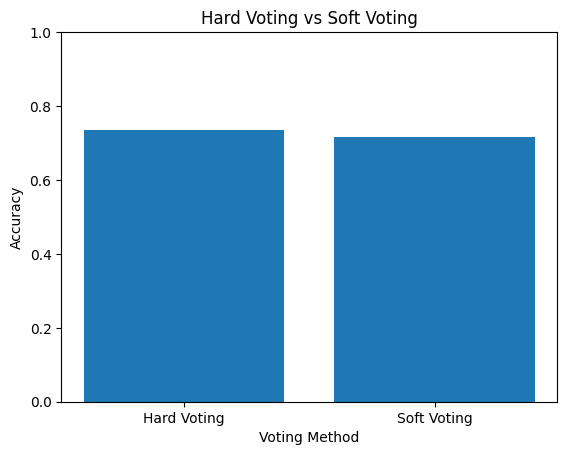

C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-


 Stacking Classifier
Accuracy: 0.7355769230769231

 Stacking Regressor
MAE: 7.817009911617772
R2 Score: 0.4933949379282939


In [23]:
# Part - E 

import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load dataset
df = pd.read_csv("Smart_Outcome_Predictor_Dataset_5200.csv.csv")

# Remove unnecessary columns
df = df.drop(columns=["student_id", "course_start_date"])

# Convert categorical data to numbers
df = pd.get_dummies(df, drop_first=True)

# Remove missing values
df = df.fillna(df.median(numeric_only=True))
df = df.fillna(0)

print("Dataset Shape:", df.shape)

# 24 Voting Classifier

from sklearn.ensemble import VotingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Classification data
X = df.drop(columns=["completion_status", "final_score"])
y = df["completion_status"]

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Base classifiers
model1 = LogisticRegression(max_iter=1000)
model2 = RandomForestClassifier(n_estimators=50, random_state=42)
model3 = KNeighborsClassifier(n_neighbors=5)

# Voting Classifier
voting_model = VotingClassifier(
    estimators=[
        ("lr", model1),
        ("rf", model2),
        ("knn", model3)
    ],
    voting="hard"
)

# Train
voting_model.fit(X_train, y_train)

# Prediction
y_pred = voting_model.predict(X_test)

print("\n Voting Classifier")
print("Accuracy:", accuracy_score(y_test, y_pred))

# 25 Hard Voting vs Soft Voting

# Hard Voting
hard_voting = VotingClassifier(
    estimators=[
        ("lr", LogisticRegression(max_iter=1000)),
        ("rf", RandomForestClassifier(n_estimators=50, random_state=42)),
        ("knn", KNeighborsClassifier(n_neighbors=5))
    ],
    voting="hard"
)

hard_voting.fit(X_train, y_train)

hard_pred = hard_voting.predict(X_test)

hard_accuracy = accuracy_score(y_test, hard_pred)


# Soft Voting
soft_voting = VotingClassifier(
    estimators=[
        ("lr", LogisticRegression(max_iter=1000)),
        ("rf", RandomForestClassifier(n_estimators=50, random_state=42)),
        ("knn", KNeighborsClassifier(n_neighbors=5))
    ],
    voting="soft"
)

soft_voting.fit(X_train, y_train)

soft_pred = soft_voting.predict(X_test)

soft_accuracy = accuracy_score(y_test, soft_pred)


print("\n Voting Comparison")
print("Hard Voting Accuracy:", hard_accuracy)
print("Soft Voting Accuracy:", soft_accuracy)

import matplotlib.pyplot as plt

models = ["Hard Voting", "Soft Voting"]
scores = [hard_accuracy, soft_accuracy]

plt.bar(models, scores)

plt.title("Hard Voting vs Soft Voting")
plt.xlabel("Voting Method")
plt.ylabel("Accuracy")
plt.ylim(0, 1)

plt.show()

# 26 Stacking Classifier

from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

# Base models
base_models = [
    ("lr", LogisticRegression(max_iter=1000)),
    ("rf", RandomForestClassifier(n_estimators=50, random_state=42)),
    ("knn", KNeighborsClassifier(n_neighbors=5))
]

# Meta learner
meta_model = LogisticRegression(max_iter=1000)

# Stacking Classifier
stacking_model = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_model
)

# Train
stacking_model.fit(X_train, y_train)

# Prediction
y_pred = stacking_model.predict(X_test)

print("\n Stacking Classifier")
print("Accuracy:", accuracy_score(y_test, y_pred))

# 27 Stacking Regressor

from sklearn.ensemble import StackingRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor

from sklearn.metrics import mean_absolute_error, r2_score

# Regression data
X_r = df.drop(columns=["final_score", "completion_status"])
y_r = df["final_score"]

# Train Test Split
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_r, y_r,
    test_size=0.20,
    random_state=42
)

# Base regression models
base_models = [
    ("lr", LinearRegression()),
    ("rf", RandomForestRegressor(
        n_estimators=50,
        random_state=42
    )),
    ("knn", KNeighborsRegressor(n_neighbors=5))
]

# Stacking Regressor
stacking_model = StackingRegressor(
    estimators=base_models,
    final_estimator=LinearRegression()
)

# Train
stacking_model.fit(X_train_r, y_train_r)

# Prediction
y_pred_r = stacking_model.predict(X_test_r)

print("\n Stacking Regressor")
print("MAE:", mean_absolute_error(y_test_r, y_pred_r))
print("R2 Score:", r2_score(y_test_r, y_pred_r))




All classification models trained!

 Classification Evaluation
               Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
0           AdaBoost  0.728846   0.723181  0.728846  0.723089  0.784320
1  Gradient Boosting  0.736538   0.731728  0.736538  0.732196  0.787712
2           LightGBM  0.714423   0.708660  0.714423  0.709607  0.765357
3            XGBoost  0.723077   0.718279  0.723077  0.719332  0.770406


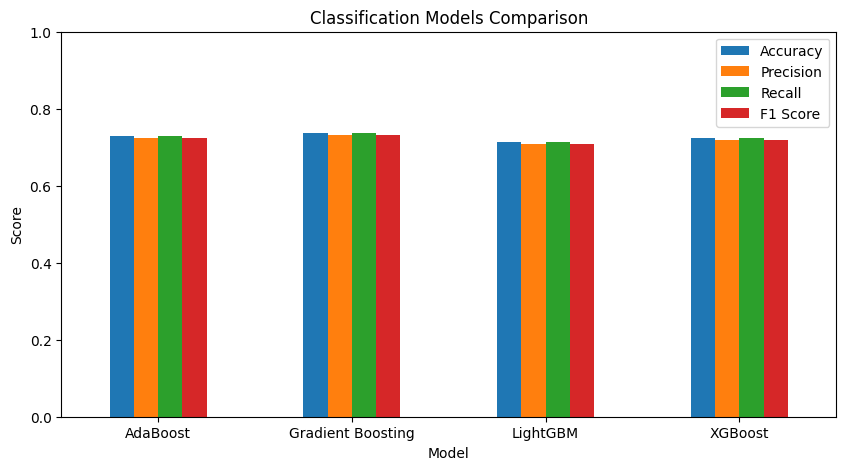

All regression models trained!

 Regression Evaluation
               Model       MAE       RMSE  R2 Score
0           AdaBoost  8.835079  10.869108  0.367706
1  Gradient Boosting  7.847619   9.804943  0.485457
2           LightGBM  8.032892  10.005249  0.464219
3            XGBoost  8.007558   9.970624  0.467921


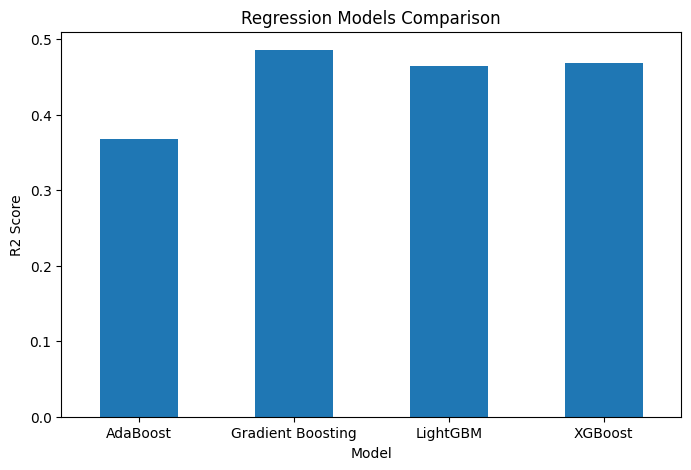


 Best Classification Model
Model: Gradient Boosting
Accuracy: 0.7365384615384616
F1 Score: 0.7321956889264581
ROC-AUC: 0.7877120315581854

 Best Regression Model
Model: Gradient Boosting
R2 Score: 0.4854574783425377
MAE: 7.8476194744502825
RMSE: 9.804942640626017

 Final Conclusion 
Best Classification Model: Gradient Boosting
Best Classification Accuracy: 0.7365
Best Regression Model: Gradient Boosting
Best Regression R2 Score: 0.4855


In [24]:
# Part - F
from sklearn.metrics import roc_auc_score
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Classification data

X = df.drop(columns=["completion_status", "final_score"])
y = df["completion_status"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# 1. AdaBoost
ada = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=50,
    random_state=42
)

# 2. Gradient Boosting
gb = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

# 3. LightGBM
lgb = LGBMClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42,
    verbose=-1
)

# 4. XGBoost
xgb = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42,
    eval_metric="logloss"
)

# Train
ada.fit(X_train, y_train)
gb.fit(X_train, y_train)
lgb.fit(X_train, y_train)
xgb.fit(X_train, y_train)

print("All classification models trained!")

# 28  Classification Evaluation

# Predictions
pred_ada = ada.predict(X_test)
pred_gb = gb.predict(X_test)
pred_lgb = lgb.predict(X_test)
pred_xgb = xgb.predict(X_test)

# ROC-AUC
auc_ada = roc_auc_score(y_test, ada.predict_proba(X_test)[:, 1])
auc_gb = roc_auc_score(y_test, gb.predict_proba(X_test)[:, 1])
auc_lgb = roc_auc_score(y_test, lgb.predict_proba(X_test)[:, 1])
auc_xgb = roc_auc_score(y_test, xgb.predict_proba(X_test)[:, 1])

# Results
classification_results = pd.DataFrame({
    "Model": [
        "AdaBoost",
        "Gradient Boosting",
        "LightGBM",
        "XGBoost"
    ],

    "Accuracy": [
        accuracy_score(y_test, pred_ada),
        accuracy_score(y_test, pred_gb),
        accuracy_score(y_test, pred_lgb),
        accuracy_score(y_test, pred_xgb)
    ],

    "Precision": [
        precision_score(y_test, pred_ada, average="weighted"),
        precision_score(y_test, pred_gb, average="weighted"),
        precision_score(y_test, pred_lgb, average="weighted"),
        precision_score(y_test, pred_xgb, average="weighted")
    ],

    "Recall": [
        recall_score(y_test, pred_ada, average="weighted"),
        recall_score(y_test, pred_gb, average="weighted"),
        recall_score(y_test, pred_lgb, average="weighted"),
        recall_score(y_test, pred_xgb, average="weighted")
    ],

    "F1 Score": [
        f1_score(y_test, pred_ada, average="weighted"),
        f1_score(y_test, pred_gb, average="weighted"),
        f1_score(y_test, pred_lgb, average="weighted"),
        f1_score(y_test, pred_xgb, average="weighted")
    ],

    "ROC-AUC": [
        auc_ada,
        auc_gb,
        auc_lgb,
        auc_xgb
    ]
})

print("\n Classification Evaluation")
print(classification_results)

classification_results.plot(
    x="Model",
    y=["Accuracy", "Precision", "Recall", "F1 Score"],
    kind="bar",
    figsize=(10, 5)
)

plt.title("Classification Models Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.show()

# 29 

# Regression data

X_r = df.drop(columns=["final_score", "completion_status"])
y_r = df["final_score"]

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_r,
    y_r,
    test_size=0.20,
    random_state=42
)

# AdaBoost
ada_r = AdaBoostRegressor(
    estimator=DecisionTreeRegressor(max_depth=2),
    n_estimators=50,
    random_state=42
)

# Gradient Boosting
gb_r = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

# LightGBM
lgb_r = LGBMRegressor(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42,
    verbose=-1
)

# XGBoost
xgb_r = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42,
    objective="reg:squarederror"
)

# Train
ada_r.fit(X_train_r, y_train_r)
gb_r.fit(X_train_r, y_train_r)
lgb_r.fit(X_train_r, y_train_r)
xgb_r.fit(X_train_r, y_train_r)

print("All regression models trained!")

# Predictions
pred_ada_r = ada_r.predict(X_test_r)
pred_gb_r = gb_r.predict(X_test_r)
pred_lgb_r = lgb_r.predict(X_test_r)
pred_xgb_r = xgb_r.predict(X_test_r)

# Results
regression_results = pd.DataFrame({
    "Model": [
        "AdaBoost",
        "Gradient Boosting",
        "LightGBM",
        "XGBoost"
    ],

    "MAE": [
        mean_absolute_error(y_test_r, pred_ada_r),
        mean_absolute_error(y_test_r, pred_gb_r),
        mean_absolute_error(y_test_r, pred_lgb_r),
        mean_absolute_error(y_test_r, pred_xgb_r)
    ],

    "RMSE": [
        np.sqrt(mean_squared_error(y_test_r, pred_ada_r)),
        np.sqrt(mean_squared_error(y_test_r, pred_gb_r)),
        np.sqrt(mean_squared_error(y_test_r, pred_lgb_r)),
        np.sqrt(mean_squared_error(y_test_r, pred_xgb_r))
    ],

    "R2 Score": [
        r2_score(y_test_r, pred_ada_r),
        r2_score(y_test_r, pred_gb_r),
        r2_score(y_test_r, pred_lgb_r),
        r2_score(y_test_r, pred_xgb_r)
    ]
})

print("\n Regression Evaluation")
print(regression_results)

regression_results.plot(
    x="Model",
    y="R2 Score",
    kind="bar",
    figsize=(8, 5),
    legend=False
)

plt.title("Regression Models Comparison")
plt.ylabel("R2 Score")
plt.xticks(rotation=0)
plt.show()

# 30 

best_classification = classification_results.loc[
    classification_results["Accuracy"].idxmax()
]

print("\n Best Classification Model")
print("Model:", best_classification["Model"])
print("Accuracy:", best_classification["Accuracy"])
print("F1 Score:", best_classification["F1 Score"])
print("ROC-AUC:", best_classification["ROC-AUC"])

best_regression = regression_results.loc[
    regression_results["R2 Score"].idxmax()
]

print("\n Best Regression Model")
print("Model:", best_regression["Model"])
print("R2 Score:", best_regression["R2 Score"])
print("MAE:", best_regression["MAE"])
print("RMSE:", best_regression["RMSE"])

print("\n Final Conclusion ")

print(
    "Best Classification Model:",
    best_classification["Model"]
)

print(
    "Best Classification Accuracy:",
    round(best_classification["Accuracy"], 4)
)

print(
    "Best Regression Model:",
    best_regression["Model"]
)

print(
    "Best Regression R2 Score:",
    round(best_regression["R2 Score"], 4)
)


Bagging Accuracy: 0.7019230769230769
AdaBoost Accuracy: 0.7288461538461538
Gradient Boosting Accuracy: 0.7365384615384616
LightGBM Accuracy: 0.7144230769230769
XGBoost Accuracy: 0.7230769230769231
               Model  Accuracy
0            Bagging  0.701923
1           AdaBoost  0.728846
2  Gradient Boosting  0.736538
3           LightGBM  0.714423
4            XGBoost  0.723077


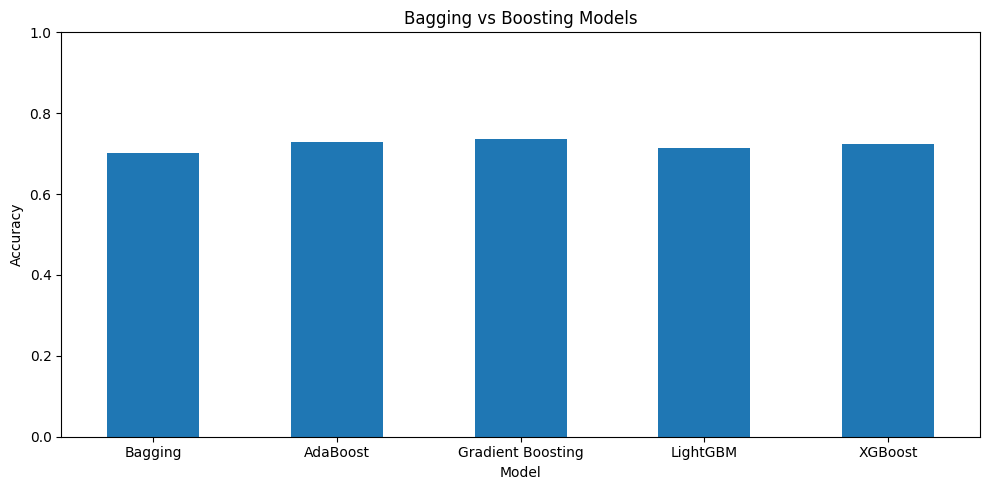

Tree-Based Boosting Models
               Model  Accuracy
0           AdaBoost  0.728846
1  Gradient Boosting  0.736538
2           LightGBM  0.714423
3            XGBoost  0.723077


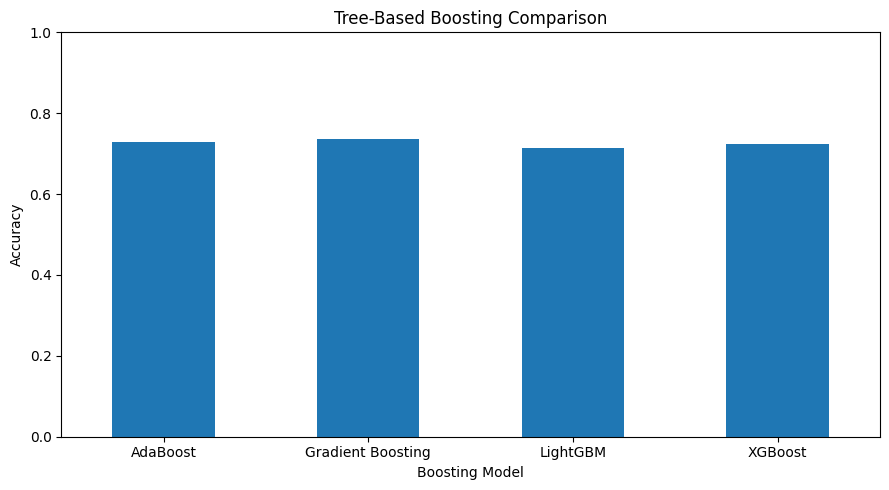

In [25]:
# Part - G 

# Final Analysis & Reporting

# Bagging vs Boosting

from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import pandas as pd
import matplotlib.pyplot as plt

# Bagging Model
bagging_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=50,
    random_state=42
)

# Train
bagging_model.fit(X_train, y_train)

# Prediction
bagging_pred = bagging_model.predict(X_test)

# Accuracy
bagging_accuracy = accuracy_score(y_test, bagging_pred)

print("Bagging Accuracy:", bagging_accuracy)

print("AdaBoost Accuracy:",
      accuracy_score(y_test, ada.predict(X_test)))

print("Gradient Boosting Accuracy:",
      accuracy_score(y_test, gb.predict(X_test)))

print("LightGBM Accuracy:",
      accuracy_score(y_test, lgb.predict(X_test)))

print("XGBoost Accuracy:",
      accuracy_score(y_test, xgb.predict(X_test)))

# Bagging vs Boosting table

final_comparison = pd.DataFrame({
    "Model": [
        "Bagging",
        "AdaBoost",
        "Gradient Boosting",
        "LightGBM",
        "XGBoost"
    ],

    "Accuracy": [
        bagging_accuracy,
        accuracy_score(y_test, ada.predict(X_test)),
        accuracy_score(y_test, gb.predict(X_test)),
        accuracy_score(y_test, lgb.predict(X_test)),
        accuracy_score(y_test, xgb.predict(X_test))
    ]
})

print(final_comparison)

# Model Comparison Chart

final_comparison.plot(
    x="Model",
    y="Accuracy",
    kind="bar",
    figsize=(10, 5),
    legend=False
)

plt.title("Bagging vs Boosting Models")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Tree Based Boosting Comparison

tree_boosting = pd.DataFrame({
    "Model": [
        "AdaBoost",
        "Gradient Boosting",
        "LightGBM",
        "XGBoost"
    ],

    "Accuracy": [
        accuracy_score(y_test, ada.predict(X_test)),
        accuracy_score(y_test, gb.predict(X_test)),
        accuracy_score(y_test, lgb.predict(X_test)),
        accuracy_score(y_test, xgb.predict(X_test))
    ]
})

print("Tree-Based Boosting Models")
print(tree_boosting)

tree_boosting.plot(
    x="Model",
    y="Accuracy",
    kind="bar",
    figsize=(9, 5),
    legend=False
)

plt.title("Tree-Based Boosting Comparison")
plt.xlabel("Boosting Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-

Voting vs Stacking
      Model  Accuracy
0    Voting  0.734615
1  Stacking  0.735577


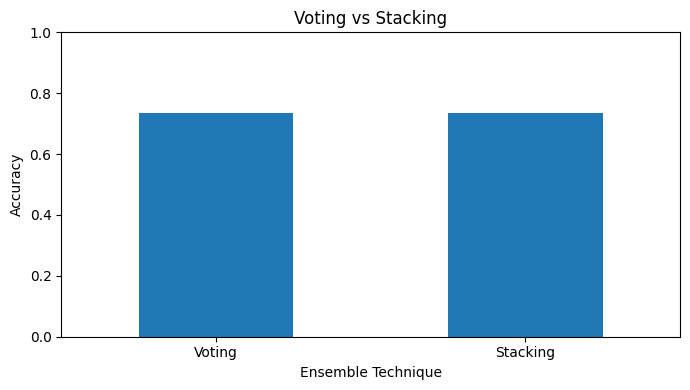

Final Model Recommendation
Best Model: Gradient Boosting
Accuracy: 0.7365


In [30]:
# Voting and Stacking Comparison

from sklearn.ensemble import (
    VotingClassifier,
    StackingClassifier
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score
import pandas as pd
import matplotlib.pyplot as plt

# Voting Classifier

voting_model_final = VotingClassifier(
    estimators=[
        ("lr", LogisticRegression(max_iter=1000)),
        ("rf", RandomForestClassifier(
            n_estimators=50,
            random_state=42
        )),
        ("knn", KNeighborsClassifier(n_neighbors=5))
    ],
    voting="hard"
)

voting_model_final.fit(X_train, y_train)

voting_pred = voting_model_final.predict(X_test)

voting_accuracy = accuracy_score(
    y_test,
    voting_pred
)

# Stacking Classifier

stacking_model_final = StackingClassifier(
    estimators=[
        ("lr", LogisticRegression(max_iter=1000)),
        ("rf", RandomForestClassifier(
            n_estimators=50,
            random_state=42
        )),
        ("knn", KNeighborsClassifier(n_neighbors=5))
    ],
    final_estimator=LogisticRegression(max_iter=1000)
)

stacking_model_final.fit(X_train, y_train)

stacking_pred = stacking_model_final.predict(X_test)

stacking_accuracy = accuracy_score(
    y_test,
    stacking_pred
)


# Comparison

voting_stacking = pd.DataFrame({
    "Model": [
        "Voting",
        "Stacking"
    ],
    "Accuracy": [
        voting_accuracy,
        stacking_accuracy
    ]
})

print("Voting vs Stacking")
print(voting_stacking)

voting_stacking.plot(
    x="Model",
    y="Accuracy",
    kind="bar",
    figsize=(7, 4),
    legend=False
)

plt.title("Voting vs Stacking")
plt.xlabel("Ensemble Technique")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Final Model Recommendation
comparison = final_comparison

best_model = comparison.loc[
    comparison["Accuracy"].idxmax()
]

print("Final Model Recommendation")

print("Best Model:", best_model["Model"])
print("Accuracy:", round(best_model["Accuracy"], 4))

Evaluation table saved successfully!


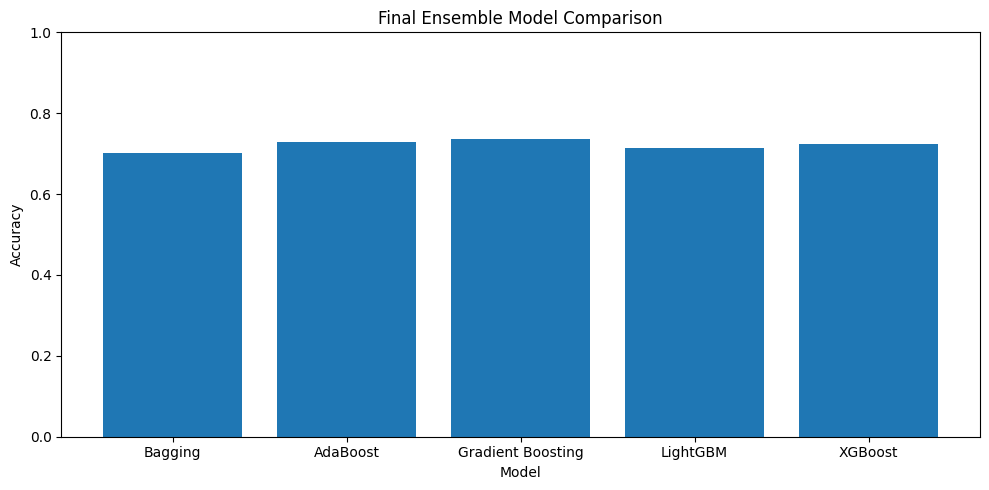

In [31]:
# Save final comparison table

final_comparison.to_csv(
    "final_model_comparison.csv",
    index=False
)

print("Evaluation table saved successfully!")

# Save comparison chart

plt.figure(figsize=(10, 5))

plt.bar(
    final_comparison["Model"],
    final_comparison["Accuracy"]
)

plt.title("Final Ensemble Model Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1)

plt.tight_layout()

plt.savefig(
    "final_ensemble_comparison.png",
    dpi=300
)

plt.show()

In [32]:
# Final Business Interpretation

print("\n Final Business Interpretation")

print("1. Bagging reduces model variance and improves stability.")

print("2. Boosting improves weak learners sequentially.")

print("3. AdaBoost focuses more on incorrectly predicted samples.")

print("4. Gradient Boosting builds models sequentially to reduce errors.")

print("5. LightGBM provides fast and efficient tree-based learning.")

print("6. XGBoost provides strong performance and robustness.")

print("7. Voting combines predictions from multiple models.")

print("8. Stacking uses a meta-learner to combine different models.")

print("9. The model with the highest accuracy is recommended.")

print("10. The final model can be used to predict student completion outcomes.")

# Q32 - Final Report

report = f"""

       Smart Outcome Predictor - Final Report

PROJECT OBJECTIVE

The objective of this project is to predict student
completion outcomes using ensemble machine learning
techniques.

DATASET

Dataset: Smart Outcome Predictor Dataset
Target for Classification: completion_status
Target for Regression: final_score

FINAL ANALYSIS


1. IMPACT OF BAGGING VS BOOSTING

Bagging trains multiple models independently and combines
their predictions. It mainly reduces variance and improves
model stability.

Boosting trains weak learners sequentially. Each new learner
tries to improve the errors made by previous learners.

2. TREE-BASED BOOSTING COMPARISON

The project evaluated:
- AdaBoost
- Gradient Boosting
- LightGBM
- XGBoost

3. VOTING AND STACKING

Voting combines predictions from multiple base models.

Stacking combines multiple models using a meta-learner.
This can improve prediction performance by learning how to
combine different model predictions.

4. FINAL MODEL RECOMMENDATION

Best Classification Model:
{best_model["Model"]}

Best Accuracy:
{best_model["Accuracy"]:.4f}

5. BUSINESS INTERPRETATION

The final model can help identify student completion
outcomes. Such predictions can help institutions identify
students who may require additional support.

CONCLUSION

Ensemble learning provides a strong approach for the
Smart Outcome Predictor project. Boosting models can provide
high predictive performance, while bagging provides stable
predictions. Voting and stacking can further combine the
strengths of multiple machine learning models.

The model with the highest evaluation score is recommended
for deployment.

End Report

"""

print(report)

with open(
    "Smart_Outcome_Predictor_Final_Report.txt",
    "w",
    encoding="utf-8"
) as file:
    file.write(report)

print("Final report saved successfully!")


 Final Business Interpretation
1. Bagging reduces model variance and improves stability.
2. Boosting improves weak learners sequentially.
3. AdaBoost focuses more on incorrectly predicted samples.
4. Gradient Boosting builds models sequentially to reduce errors.
5. LightGBM provides fast and efficient tree-based learning.
6. XGBoost provides strong performance and robustness.
7. Voting combines predictions from multiple models.
8. Stacking uses a meta-learner to combine different models.
9. The model with the highest accuracy is recommended.
10. The final model can be used to predict student completion outcomes.


       Smart Outcome Predictor - Final Report

PROJECT OBJECTIVE

The objective of this project is to predict student
completion outcomes using ensemble machine learning
techniques.

DATASET

Dataset: Smart Outcome Predictor Dataset
Target for Classification: completion_status
Target for Regression: final_score

FINAL ANALYSIS


1. IMPACT OF BAGGING VS BOOSTING

Bagging trai